# Notebook 02 — Preprocessing & Data Preparation
**Project:** Cost-Sensitive Deep Learning for Early Clinical Deterioration Prediction in ICU Patients  
**Input:** `data/training_v2.csv`  
**Output:** `data/train.csv`, `data/val.csv`, `data/test.csv`

## 0. Imports

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from imblearn.over_sampling import SMOTENC
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [23]:
df = pd.read_csv('data/training_v2.csv')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Target distribution:\n{df["hospital_death"].value_counts()}')

Loaded: 91,713 rows x 186 columns
Target distribution:
hospital_death
0    83798
1     7915
Name: count, dtype: int64


## 2. Drop Useless Columns

In [24]:
# 2a. Drop ID columns — not useful for prediction
id_cols = ['encounter_id', 'patient_id', 'hospital_id', 'icu_id']
df.drop(columns=[c for c in id_cols if c in df.columns], inplace=True)
print(f'After dropping ID cols: {df.shape}')

After dropping ID cols: (91713, 182)


In [25]:
# 2b. Drop columns with more than 60% missing values
missing_pct = df.isnull().mean()
high_missing = missing_pct[missing_pct > 0.60].index.tolist()

print(f'Columns to drop (>60% missing): {len(high_missing)}')
df.drop(columns=high_missing, inplace=True)
print(f'After dropping high-missing cols: {df.shape}')

Columns to drop (>60% missing): 66
After dropping high-missing cols: (91713, 116)


In [26]:
# 2c. Drop columns with near-zero variance (constant columns)
num_df = df.select_dtypes(include=[np.number])
low_var = num_df.columns[num_df.std() < 0.01].tolist()

print(f'Low variance columns to drop: {low_var}')
df.drop(columns=low_var, inplace=True)
print(f'After dropping low-variance cols: {df.shape}')

Low variance columns to drop: ['readmission_status']
After dropping low-variance cols: (91713, 115)


## 3. Separate Target & Features

In [27]:
TARGET = 'hospital_death'

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Target balance : {y.value_counts().to_dict()}')

Features shape : (91713, 114)
Target shape   : (91713,)
Target balance : {0: 83798, 1: 7915}


## 4. Handle Categorical Columns

In [28]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Categorical columns (8): ['ethnicity', 'gender', 'hospital_admit_source', 'icu_admit_source', 'icu_stay_type', 'icu_type', 'apache_3j_bodysystem', 'apache_2_bodysystem']


In [29]:
# Identify categorical columns and handle cardinality
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

# One-hot encode categoricals with low cardinality
# For high cardinality (>10 unique), drop — too many dummies would hurt the model
to_encode = [c for c in cat_cols if X[c].nunique() <= 10]
to_drop_cat = [c for c in cat_cols if X[c].nunique() > 10]

print(f'Encoding  : {to_encode}')
print(f'Dropping  : {to_drop_cat}')

# Drop high-cardinality categoricals now; keep low-cardinality categoricals as-is (will ordinal-encode later for SMOTENC)
X.drop(columns=to_drop_cat, inplace=True)

print(f'\nAfter dropping high-cardinality categoricals: {X.shape}')

Categorical columns (8): ['ethnicity', 'gender', 'hospital_admit_source', 'icu_admit_source', 'icu_stay_type', 'icu_type', 'apache_3j_bodysystem', 'apache_2_bodysystem']
Encoding  : ['ethnicity', 'gender', 'icu_admit_source', 'icu_stay_type', 'icu_type', 'apache_2_bodysystem']
Dropping  : ['hospital_admit_source', 'apache_3j_bodysystem']

After dropping high-cardinality categoricals: (91713, 112)


## 5. Train / Validation / Test Split
**Strategy:** 70% train | 15% validation | 15% test  
**Stratified** to preserve the 11:1 imbalance ratio in all splits

In [30]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: 50/50 on temp → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train : {X_train.shape} | Died: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Val   : {X_val.shape}   | Died: {y_val.sum()} ({y_val.mean()*100:.1f}%)')
print(f'Test  : {X_test.shape}  | Died: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Train : (64199, 112) | Died: 5540 (8.6%)
Val   : (13757, 112)   | Died: 1188 (8.6%)
Test  : (13757, 112)  | Died: 1187 (8.6%)


## 6. Impute Missing Values
**Strategy:**  
- Numerical → median (robust to outliers in clinical data)  
- Fit on train only, transform all splits (no data leakage)

In [31]:
# Compute medians from training set only
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
train_medians = X_train[num_cols].median()

# Apply to all splits
X_train[num_cols] = X_train[num_cols].fillna(train_medians)
X_val[num_cols]   = X_val[num_cols].fillna(train_medians)
X_test[num_cols]  = X_test[num_cols].fillna(train_medians)

# Verify no missing values remain
print(f'Missing after imputation:')
print(f'  Train : {X_train.isnull().sum().sum()}')
print(f'  Val   : {X_val.isnull().sum().sum()}')
print(f'  Test  : {X_test.isnull().sum().sum()}')

Missing after imputation:
  Train : 2247
  Val   : 474
  Test  : 473


## 7. Feature Scaling
**StandardScaler:** mean=0, std=1  
Fit on train only → transform all splits

In [32]:
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols]   = scaler.transform(X_val[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print('Scaling done.')
example_col = 'heart_rate_mean' if 'heart_rate_mean' in X_train.columns else (num_cols[0] if len(num_cols) > 0 else None)
if example_col:
    print(f'Example — {example_col}: mean={X_train[example_col].mean():.4f}, std={X_train[example_col].std():.4f}')
else:
    print('No numeric columns available to show example.')

Scaling done.
Example — age: mean=-0.0000, std=1.0000


## 8. SMOTE — Handle Class Imbalance
**Applied on training set ONLY**  
Creates synthetic dying patient examples to balance the dataset  
Val and test sets stay imbalanced (reflects real world)

In [33]:
print('Before SMOTE:')
print(f'  Survived: {(y_train==0).sum():,}')
print(f'  Died    : {(y_train==1).sum():,}')
print(f'  Ratio   : {(y_train==0).sum() / (y_train==1).sum():.1f}:1')

Before SMOTE:
  Survived: 58,659
  Died    : 5,540
  Ratio   : 10.6:1


Before SMOTENC:
  Survived: 58,659
  Died    : 5,540
After SMOTENC:
  Survived: 58,659
  Died    : 58,659


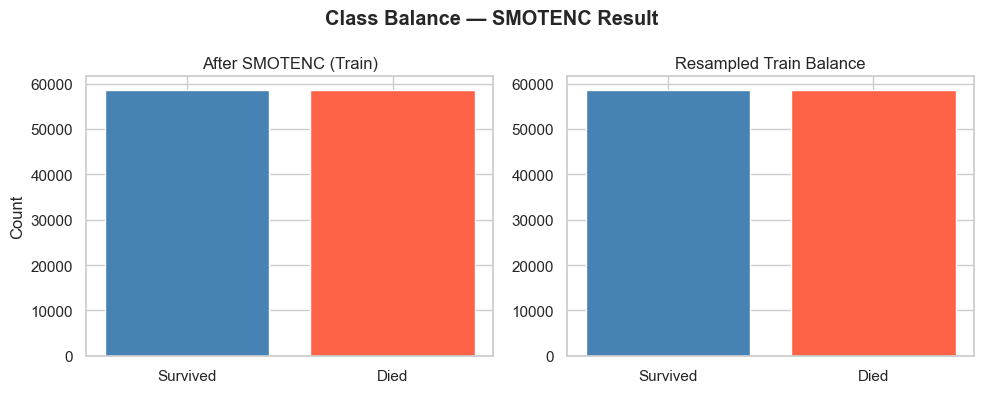

In [34]:
# SMOTENC: integer-encode categoricals, resample training set, then one-hot if needed
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTENC

# Impute categorical NaNs on training set (mode) and apply to val/test
for c in to_encode:
    mode = X_train[c].mode().iloc[0] if c in X_train.columns else None
    if mode is not None:
        X_train[c] = X_train[c].fillna(mode)
        X_val[c]   = X_val[c].fillna(mode)
        X_test[c]  = X_test[c].fillna(mode)

# Ordinal-encode categoricals (fit on train)
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_enc = X_train.copy()
X_val_enc = X_val.copy()
X_test_enc = X_test.copy()

if len(to_encode) > 0:
    X_train_enc[to_encode] = enc.fit_transform(X_train[to_encode]).astype(int)
    X_val_enc[to_encode]   = enc.transform(X_val[to_encode]).astype(int)
    X_test_enc[to_encode]  = enc.transform(X_test[to_encode]).astype(int)

    # Save encoder for later use
    joblib.dump(enc, 'data/ordinal_encoder.joblib')

# Determine categorical feature indices for SMOTENC
cat_idxs = [X_train_enc.columns.get_loc(c) for c in to_encode] if len(to_encode) > 0 else []

print('Before SMOTENC:')
print(f'  Survived: {(y_train==0).sum():,}')
print(f'  Died    : {(y_train==1).sum():,}')

# Apply SMOTENC on training set only
smote = SMOTENC(categorical_features=cat_idxs, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_enc, y_train)

print('After SMOTENC:')
print(f'  Survived: {(y_train_res==0).sum():,}')
print(f'  Died    : {(y_train_res==1).sum():,}')

# After resampling, one-hot encode categorical cols if model requires it
if len(to_encode) > 0:
    X_train_res = pd.get_dummies(X_train_res, columns=to_encode, drop_first=True)
    X_val_d = pd.get_dummies(X_val_enc, columns=to_encode, drop_first=True)
    X_test_d = pd.get_dummies(X_test_enc, columns=to_encode, drop_first=True)

    # Align val/test to train columns
    X_val_res = X_val_d.reindex(columns=X_train_res.columns, fill_value=0)
    X_test_res = X_test_d.reindex(columns=X_train_res.columns, fill_value=0)
else:
    X_train_res = X_train_res
    X_val_res = X_val_enc
    X_test_res = X_test_enc

# Replace training/val/test variables used later
X_train = X_train_res.copy()
X_val = X_val_res.copy()
X_test = X_test_res.copy()

# Update y_train
y_train = y_train_res.copy()

# Visualize class balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Survived', 'Died'], [(y_train==0).sum(), (y_train==1).sum()], color=['steelblue', 'tomato'])
axes[0].set_title('After SMOTENC (Train)')
axes[0].set_ylabel('Count')

axes[1].bar(['Survived', 'Died'], [(y_train_res==0).sum(), (y_train_res==1).sum()], color=['steelblue', 'tomato'])
axes[1].set_title('Resampled Train Balance')

plt.suptitle('Class Balance — SMOTENC Result', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_smote_balance.png', bbox_inches='tight')
plt.show()

## 9. Compute Class Weights (for cost-sensitive loss)
Used in Notebook 04 — Deep Learning  
Alternative to SMOTE, or can be combined

In [35]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)

print(f'Class weights:')
print(f'  Survived (0) : {class_weights[0]:.4f}')
print(f'  Died     (1) : {class_weights[1]:.4f}')
print(f'  Ratio        : {class_weights[1]/class_weights[0]:.1f}x more weight on dying patients')

Class weights:
  Survived (0) : 1.0000
  Died     (1) : 1.0000
  Ratio        : 1.0x more weight on dying patients


## 10. Save Processed Data

In [ ]:
# Save all splits
train_out = X_train.copy()
train_out['hospital_death'] = y_train.values

val_out = X_val.copy()
val_out['hospital_death'] = y_val.values

test_out = X_test.copy()
test_out['hospital_death'] = y_test.values

train_out.to_csv('data/train.csv', index=False)
val_out.to_csv('data/val.csv',   index=False)
test_out.to_csv('data/test.csv',  index=False)

# Save class weights for later use
import json
with open('data/class_weights.json', 'w') as f:
    json.dump({'0': class_weights[0], '1': class_weights[1]}, f)

print('Saved:')
print(f'  data/train.csv  → {train_out.shape}')
print(f'  data/val.csv    → {val_out.shape}')
print(f'  data/test.csv   → {test_out.shape}')
print(f'  data/class_weights.json')

Saved:
  data/train.csv  → (117318, 135)
  data/val.csv    → (13757, 135)
  data/test.csv   → (13757, 135)
  data/class_weights.json


## 11. Preprocessing Summary

In [37]:
print('=' * 55)
print('PREPROCESSING SUMMARY')
print('=' * 55)
print(f'Original dataset          : 91,713 rows x 186 cols')
print(f'After dropping ID cols    : removed 4 columns')
print(f'After dropping >60% miss  : removed {len(high_missing)} columns')
print(f'After encoding categoricals: {X.shape[1]} features')
print(f'Imputation strategy       : median (fit on train only)')
print(f'Scaling strategy          : StandardScaler (fit on train only)')
print(f'SMOTE                     : balanced training set to 1:1')
print(f'Class weights             : [0]={class_weights[0]:.2f} | [1]={class_weights[1]:.2f}')
print()
print('Final splits:')
print(f'  Train (after SMOTE) : {train_out.shape}')
print(f'  Validation          : {val_out.shape}')
print(f'  Test                : {test_out.shape}')
print()
print('→ Next: Notebook 03_Baseline_Models.ipynb')

PREPROCESSING SUMMARY
Original dataset          : 91,713 rows x 186 cols
After dropping ID cols    : removed 4 columns
After dropping >60% miss  : removed 66 columns
After encoding categoricals: 112 features
Imputation strategy       : median (fit on train only)
Scaling strategy          : StandardScaler (fit on train only)
SMOTE                     : balanced training set to 1:1
Class weights             : [0]=1.00 | [1]=1.00

Final splits:
  Train (after SMOTE) : (117318, 135)
  Validation          : (13757, 135)
  Test                : (13757, 135)

→ Next: Notebook 03_Baseline_Models.ipynb
